In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import plotly.express as px
from sklearn.metrics import accuracy_score

# **PREDICCION BOMBAS DEFECTUOSAS PARA FAVORECER ACCESO A AGUA POTABLE TANZANIA**

**1.Lectura de datos disponibles y union de tablas:**

In [ ]:
entrenamiento = pd.read_csv('/content/drive/MyDrive/Master UCM/machine learning/tarea/valores entrenamiento/4910797b-ee55-40a7-8668-10efd5c1b960.csv', index_col=0)
test = pd.read_csv('/content/drive/MyDrive/Master UCM/machine learning/tarea/valores pruebas/702ddfc5-68cd-4d1d-a0de-f5f566f76d91.csv',index_col=0)
labels = pd.read_csv('/content/drive/MyDrive/Master UCM/machine learning/tarea/etiquetas entrenamiento/0bf8bc6e-30d0-4c50-956a-603fc693d966.csv',index_col=0)

In [ ]:
print("Tabla entrenamiento",entrenamiento.shape)
print("Tabla test", test.shape)
print("Tabla labels",labels.shape)

Tabla entrenamiento (59400, 39)
Tabla test (14850, 39)
Tabla labels (59400, 1)


In [ ]:
pd.Series(labels.index.isin(entrenamiento.index)).value_counts()

,count
True,59400


Vemos que el tamaño de las tablas que queremos unir coincide en el numero de filas y no falta ningun indice. Nuestro dataset de entrenamiento será "df", el cual contiene nuestra variable objetivo "status_group".

In [ ]:
df = entrenamiento.merge(labels, on="id")


X = df.drop("status_group", axis=1)
y = df["status_group"]

**2.Analisis exploratorio (EDA)**

**2.1 Tipos y vision inicial**

<Axes: title={'center': 'Distribución variable objetivo'}, xlabel='status_group'>

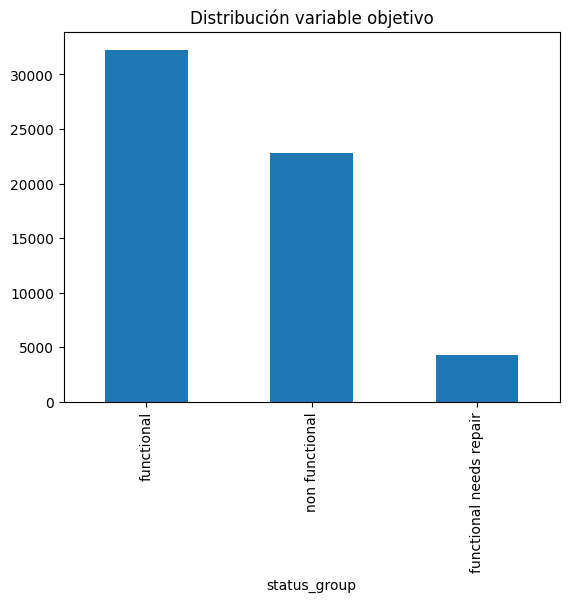

In [ ]:
df["status_group"].value_counts().plot(kind="bar", title="Distribución variable objetivo")

En esta tabla podemos ver que la variable objetivo esta desbalanceada en nuestro dataset, esto lo tendremos en cuenta en el modelado ya que puede influir favoreciendo a la clase "funcional" que cuenta con bastantes mas datos y perjudicando a las otras.

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
amount_tsh,59400.0,NaN,NaN,NaN,317.650385,2997.574558,0.0,0.0,0.0,20.0,350000.0
date_recorded,59400,356,2011-03-15,572,NaN,NaN,NaN,NaN,NaN,NaN,NaN
funder,55763,1896,Government Of Tanzania,9084,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gps_height,59400.0,NaN,NaN,NaN,668.297239,693.11635,-90.0,0.0,369.0,1319.25,2770.0
installer,55745,2145,DWE,17402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
longitude,59400.0,NaN,NaN,NaN,34.077427,6.567432,0.0,33.090347,34.908743,37.178387,40.345193
latitude,59400.0,NaN,NaN,NaN,-5.706033,2.946019,-11.64944,-8.540621,-5.021597,-3.326156,-0.0
wpt_name,59398,37399,none,3563,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_private,59400.0,NaN,NaN,NaN,0.474141,12.23623,0.0,0.0,0.0,0.0,1776.0
basin,59400,9,Lake Victoria,10248,NaN,NaN,NaN,NaN,NaN,NaN,NaN


En una observacion inicial podemos ver que hay variables con muchos missings, otras con mucha cardinalidad y nos llaman la atencion distribuciones "raras".

In [ ]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "n_missing": df.isnull().sum(),
    "missing_%": (df.isnull().sum() / len(df)) * 100
})

summary = summary.sort_values(by="n_unique", ascending=False)

summary

,dtype,n_unique,n_missing,missing_%
latitude,float64,57517,0,0.000000
longitude,float64,57516,0,0.000000
wpt_name,object,37399,2,0.003367
subvillage,object,19287,371,0.624579
scheme_name,object,2695,28810,48.501684
gps_height,int64,2428,0,0.000000
installer,object,2145,3655,6.153199
ward,object,2092,0,0.000000
funder,object,1896,3637,6.122896
population,int64,1049,0,0.000000


En el sumary de nuestro dataset podemos observar las siguentes cosas a mejorar:


1.   Date recorde como object en lugar de fecha
2.   Public_meeting como object en lugar de booleano
3.   Permit como objet en lugar de booleano
4.  Recorded_by con 1 unico valor, no aporta informacion al modelo

Varias variables con muchos missings y cardinalidad alta que veremos mejor graficamente.



# **2.2.Estudio de cardinalidad y missings.**

<Axes: title={'center': 'Top variables con más cardinalidad'}>

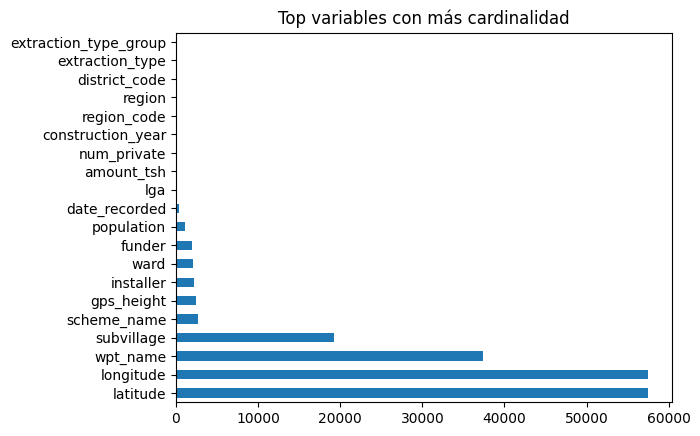

In [ ]:
df.nunique().sort_values(ascending=False).head(20).plot(kind="barh", title="Top variables con más cardinalidad")

En la grafica podemos ver variables con altisima cardinalidad, destacan latitude y longitude con casi el 100% de los datos diferentes, aunque al ser continuas es algo esperable y no le damos tanta importancia. wpt_name tiene mas del 60% y es categorica, lo cual la hace clara candidata de eliminacion. Subvillage tambien tiene buen porcentaje y estudiaremos su impacto en el modelo para ver si la mantenemos o no.

<Axes: title={'center': 'Top variables con más valores nulos'}>

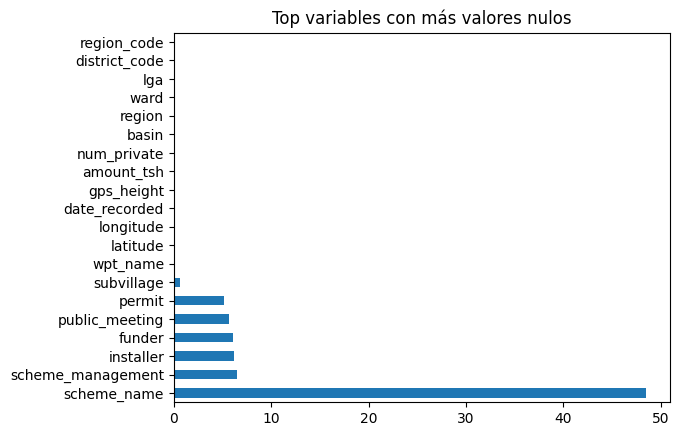

In [ ]:
(df.isnull().mean()*100).sort_values(ascending=False).head(20).plot(kind="barh", title="Top variables con más valores nulos")

En la grafica podemos observar la cantidad de nulos por variable con la variable scheme_name con casi el 50%, lo cual la hace muy candidata de eliminación, mientras que las demas con un maximo de aprox 6% podemos trabajar con ellas para imputar sin tener que eliminarlas.

**2.3.RELACION DE LAS VARIABLES CATEGORICAS CON LA OBJETIVO CON CRAMER**

In [ ]:
def cramers_v(var1, varObj):
    data = pd.crosstab(var1, varObj).values
    vCramer = stats.contingency.association(data, method='cramer')
    return vCramer

In [ ]:
tablaCramer = pd.DataFrame(
    df.select_dtypes(include="object")
      .drop(columns=["status_group"])
      .apply(lambda x: cramers_v(x, df["status_group"])),
    columns=["VCramer"]
)


tablaCramer = tablaCramer.sort_values(by="VCramer", ascending=False)


print(tablaCramer.head(10))


px.bar(
    tablaCramer.head(10),
    x="VCramer",
    title="Relación de variables categóricas con status_group"
).update_yaxes(categoryorder="total ascending")


/usr/local/lib/python3.12/dist-packages/scipy/stats/contingency.py:512: RuntimeWarning:

invalid value encountered in scalar divide



                  VCramer
wpt_name         0.809522
subvillage       0.682880
scheme_name      0.593358
ward             0.469122
installer        0.363391
funder           0.356485
lga              0.311533
quantity         0.309240
quantity_group   0.309240
waterpoint_type  0.250426


Con el analisis de V de cramer vemos que la relacion de las variables con nuestra variable objetivo por lo cual:


1.   wpt_name relacion muy alta con la objetivo, pero con la gran cardinalidad de esta puede crear overfitting, la eliminamos.
2.   subvillage tambien gran relacion, aun con su gran cardinalidad vamos a tratarla para incluirla en el modelo.
3.   scheme_name tiene relacion alta pero con su elevada cantidad de missings nos puede ser problematica, la eliminamos.

**2.4. Distribuciones**

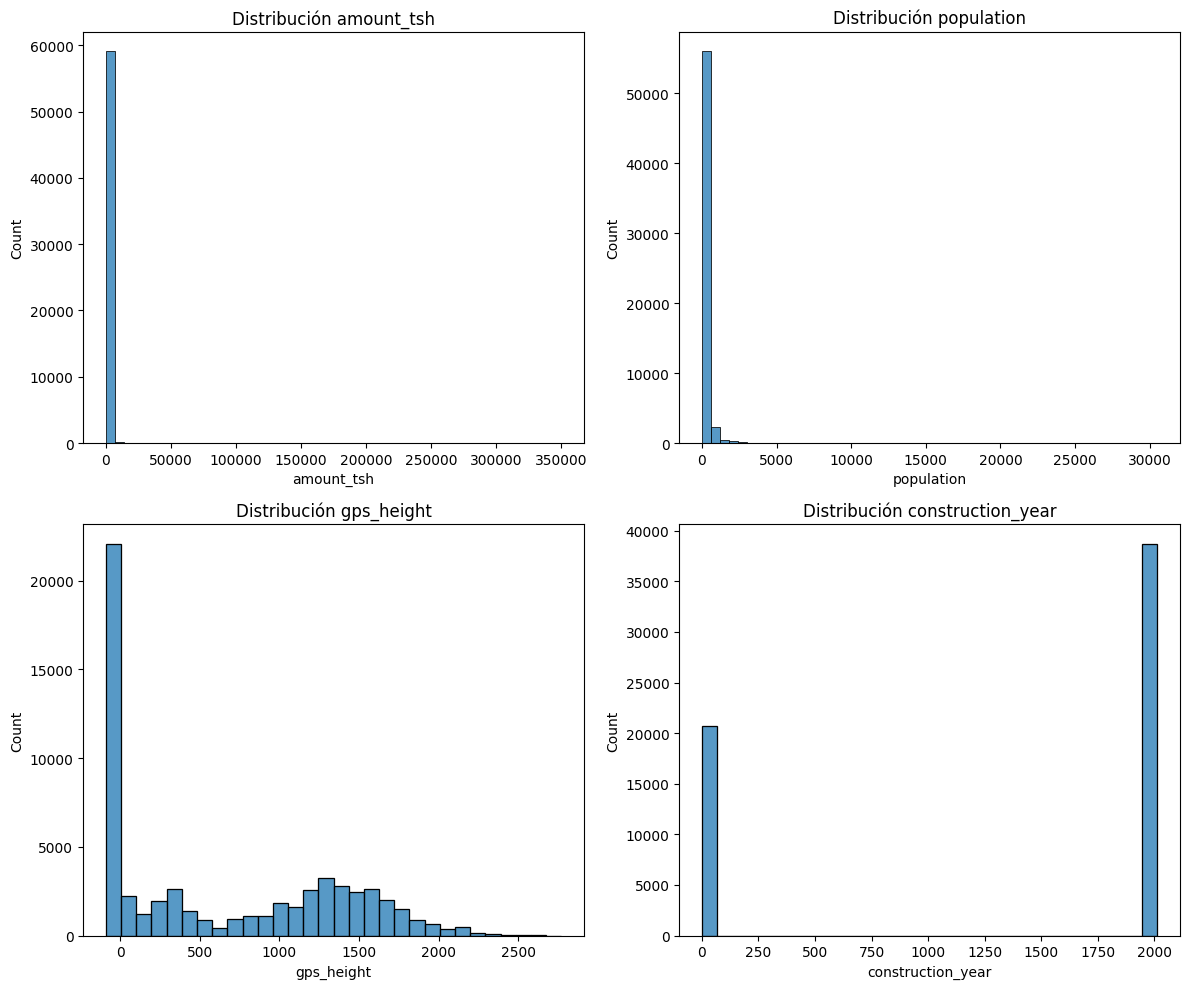

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(df["amount_tsh"], bins=50, ax=axes[0,0])
axes[0,0].set_title("Distribución amount_tsh")


sns.histplot(df["population"], bins=50, ax=axes[0,1])
axes[0,1].set_title("Distribución population")


sns.histplot(df["gps_height"], bins=30, ax=axes[1,0])
axes[1,0].set_title("Distribución gps_height")


sns.histplot(df["construction_year"], bins=30, ax=axes[1,1])
axes[1,1].set_title("Distribución construction_year")

plt.tight_layout()
plt.show()

Se pinta la distribucion de variables que en el analisis inicial nos llaman la atencion por su asimetria y por la presencia de valores extremos que pueden sesgar los datos o ser 0 encubiertos.

In [ ]:
cols = ["amount_tsh", "construction_year", "population", "gps_height"]

pd.DataFrame({
    "n_ceros": (df[cols] == 0).sum(),
    "n_no_ceros": (df[cols] != 0).sum(),
    "porcentaje_ceros": ((df[cols] == 0).mean() * 100)
})

,n_ceros,n_no_ceros,porcentaje_ceros
amount_tsh,41639,17761,70.099327
construction_year,20709,38691,34.863636
population,21381,38019,35.994949
gps_height,20438,38962,34.407407


construction_year no es posible que sea 0, lo pasamos a NaN y amount_ths con un 70% probablemente sean datos faltantes y nos va a sesgar, las otras vamos a dejarlas.

**3. Limpieza**

**3.1 Tipos**

In [ ]:
#1. Convertir a fecha
df["date_recorded"] = pd.to_datetime(df["date_recorded"], errors="coerce")

df["year_recorded"] = df["date_recorded"].dt.year
df["month_recorded"] = df["date_recorded"].dt.month

In [ ]:
#2. Convertir a booleanos
df["public_meeting"] = df["public_meeting"].replace({
    "True": True, "False": False,
    True: True, False: False
}).astype("boolean")

df["permit"] = df["permit"].replace({
    "True": True, "False": False,
    True: True, False: False
}).astype("boolean")


**3.2 Variables eliminadas**

In [ ]:
cols_borradas = [
    "wpt_name", "scheme_name", "recorded_by",
    "extraction_type_group", "extraction_type_class",
    "management_group",
    "payment_type",
    "quality_group",
    "quantity_group",
    "source_type", "source_class",
    "waterpoint_type_group"
]

df = df.drop(columns=cols_borradas)


Se han observado columnas con informacion redundante, se eliminan para mejorar en eficiencia en el modelado junto con las problematicas por missings y cardinalidad y la que no nos daba informacion.

**3.3 Ceros a NaN**

In [ ]:
df["construction_year"] = df["construction_year"].replace(0, np.nan)
df["amount_tsh"] = df["amount_tsh"].replace(0, np.nan)

**3.4 Transformacion de variables**

In [ ]:
df["edad_buena"] = df["year_recorded"] - df["construction_year"]

df = df.drop("date_recorded", axis=1)

df["Tiene_poblacion"] = (df["population"] > 0).astype(int)

<Axes: xlabel='amount_tsh_log', ylabel='Count'>

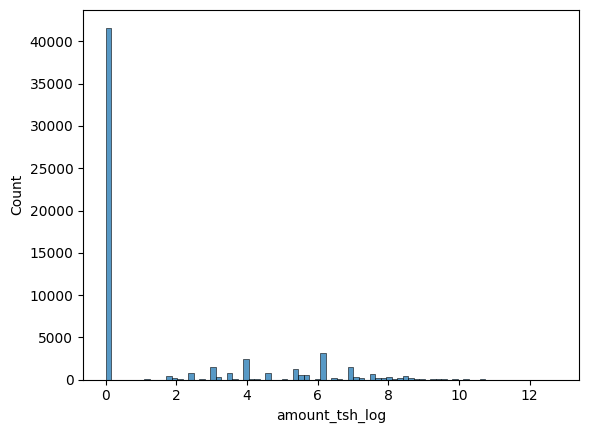

In [ ]:
df["amount_tsh_log"] = np.log1p(df["amount_tsh"])
sns.histplot(df["amount_tsh_log"])

Se crean variables nuevas que aportan mas informacion  o se transforman como en el caso de amount_tsh para mejorar su distribucion.

**3.6 Agrupar columnas con valores raros**

In [ ]:
top_funders = df["funder"].value_counts().head(10).index

df["funder_agrupado"] = df["funder"].apply(
    lambda x: x if x in top_funders else "raros"
)

top_subvillage = df["subvillage"].value_counts().head(10).index

df["subvillage_agrupado"] = df["subvillage"].apply(
    lambda x: x if x in top_subvillage else "raros"
)

Para reducir complejidad del modelo agrupamos en valores raros subvillage que la teniamos pendiente de estudio por cardinalidad alta, hacemos lo mismo con funder.

In [ ]:
X=df.drop("status_group", axis=1)
y=df["status_group"]


df = df[X.columns]

**4. Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**5.Preprocesado**

In [ ]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# pipelines
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

Se realiza un preprocesado separando varibales numericas (imputacion por mediana) y categoricas(imputacion por mas frecuente) para tratarlas e imputar diferente, en las categoricas se usa One Hot encoding para convertirlas en numericas sin tener relaciones entre categorias y poderlas usar.

**6. Modelos**

**6.1 Logistic**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

pipeline_lr = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))
])


pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_val)


print("LR Accuracy:", accuracy_score(y_val, y_pred_lr))
print(classification_report(y_val, y_pred_lr))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LR Accuracy: 0.6341750841750842
                         precision    recall  f1-score   support

             functional       0.77      0.66      0.71      6457
functional needs repair       0.19      0.66      0.30       851
         non functional       0.79      0.59      0.68      4572

               accuracy                           0.63     11880
              macro avg       0.58      0.64      0.56     11880
           weighted avg       0.74      0.63      0.67     11880



**6.2 SVM**

In [ ]:
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

pipeline_svm = Pipeline([
    ("prep", preprocessor),
    ("model", LinearSVC(max_iter=2000, class_weight="balanced"))
])

pipeline_svm.fit(X_train, y_train)

y_pred_svm = pipeline_svm.predict(X_val)

print("SVM Accuracy:", accuracy_score(y_val, y_pred_svm))

SVM Accuracy: 0.7666666666666667


**6.3 Random forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
("prep", preprocessor),
("model", RandomForestClassifier(
class_weight = "balanced",
random_state=42,
max_depth=None,
min_samples_split=5))])

pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_val)

print(accuracy_score(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf))

0.7955387205387205
                         precision    recall  f1-score   support

             functional       0.83      0.84      0.83      6457
functional needs repair       0.43      0.46      0.45       851
         non functional       0.82      0.79      0.81      4572

               accuracy                           0.80     11880
              macro avg       0.69      0.70      0.70     11880
           weighted avg       0.80      0.80      0.80     11880



In [ ]:
print("Accuracy:", accuracy_score(y_val, y_pred_rf))

Accuracy: 0.7955387205387205


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred_rf))

                         precision    recall  f1-score   support

             functional       0.83      0.84      0.83      6457
functional needs repair       0.43      0.46      0.45       851
         non functional       0.82      0.79      0.81      4572

               accuracy                           0.80     11880
              macro avg       0.69      0.70      0.70     11880
           weighted avg       0.80      0.80      0.80     11880



**6.4 Comparación**

In [ ]:
tabla_resultados = pd.DataFrame({
    "Modelo": ["Random Forest", "Logistic Regresion", "SVM"],
    "Accuracy": [
        accuracy_score(y_val, y_pred_rf),
        accuracy_score(y_val, y_pred_lr),
        accuracy_score(y_val, y_pred_svm)
    ]
})

tabla_resultados.sort_values(by="Accuracy", ascending=False)

,Modelo,Accuracy
0,Random Forest,0.795539
2,SVM,0.766667
1,Logistic Regresion,0.634175


Se comparan 3 modelos mediante el accuracy y el que mejor resultados nos muestra es el Random Forest seguido por SVM, logistic regresion no da buen resultado.Random forest es el que captura mejor las relaciones del df y con el que haremos el test final.

**6.4 Matriz confucion Random Forest**

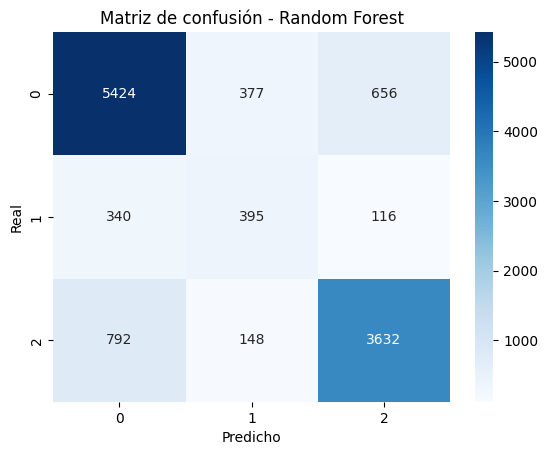

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión - Random Forest")
plt.show()

Como vimos al principio hay un gran desbalanceo en los datos que queda reflejado en la matriz de confusion, con el balanceo de clases de los modelos lo hemos mitigado pero aun asi las clases conmenos datos tienen mas dificultad para predecir.

**6.5 Test + submission**

In [ ]:
test["date_recorded"] = pd.to_datetime(test["date_recorded"], errors="coerce")

test["year_recorded"] = test["date_recorded"].dt.year
test["month_recorded"] = test["date_recorded"].dt.month


#Booleanos
test["public_meeting"] = test["public_meeting"].replace({
    "True": True, "False": False,
    True: True, False: False
}).astype("boolean")

test["permit"] = test["permit"].replace({
    "True": True, "False": False,
    True: True, False: False
}).astype("boolean")


#Ceros a NaN
test["construction_year"] = test["construction_year"].replace(0, np.nan)
test["amount_tsh"] = test["amount_tsh"].replace(0, np.nan)


#Transformación de variables
test["edad_buena"] = test["year_recorded"] - test["construction_year"]

test["Tiene_poblacion"] = (test["population"] > 0).astype(int)

test["amount_tsh_log"] = np.log1p(test["amount_tsh"])


#Agrupación
test["funder_agrupado"] = test["funder"].apply(
    lambda x: x if x in top_funders else "raros"
)

test["subvillage_agrupado"] = test["subvillage"].apply(
    lambda x: x if x in top_subvillage else "raros"
)


#Borrado
test = test.drop(columns=cols_borradas, errors="ignore")

test = test.drop("date_recorded", axis=1)

test = test[X.columns]

In [ ]:
pipeline_rf.fit(X, y)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['amount_tsh', 'gps_height', 'longitude', 'latitude', 'num_private',
       'region_code', 'district_code', 'population', 'construction_year',
       'edad_buena', 'Tiene_poblacion', 'amount_tsh_log'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['funder', 'installer', 'basin', 'subvillage', 'region', 'lga', 'ward',
       'scheme_management', 'extraction_type', 'management', 'payment',
       'water_quality', 'quantity', 'source', 'waterpoint_type',
       'funder_agrupado', 'subvillage_agrupado'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_split=5,
                                        random_state=42))])

In [ ]:
preds = pipeline_rf.predict(test)

In [ ]:
submission = pd.DataFrame({
    "id": test.index,
    "status_group": preds
})

In [ ]:
submission.to_csv("submission16.csv", index=False)

In [ ]:
from google.colab import files
files.download("submission16.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**7.Conclusion y limitaciones**

El uso de tecnicas de proprocesado ha permitido mejorar y optimizar el comportamiento del modelo iterando entre diferentes parametros primero para obtener un score mayor y luego para mejorar el rendimiento y optimizar el tiempo. Tambien se han provado otras tecnicas como Naive Bayes que finalmente fueron descartadas.
El modelo final elegido ha sido Random Forest optimizado aun con la limitacion de clases por el desbalanceo del dataset.